# Neural ODE Implementation in nnodely: Mass Spring Damper

This section presents a Neural ODE model in nnodely for learning the continuous-time dynamics of the mass spring damper.

In [1]:
import os
from nnodely import *
import numpy as np
import matplotlib.pyplot as plt
from nnodely.support import earlystopping
from nnodely.support.odeint.adjoint import odeint_adjoint

def init_random_range(indexes, params_size, dict_param={'min_value': 0.0, 'max_value': 1.0}):
    import numpy as np
    min_val = dict_param.get('min_value', 0.0)
    max_val = dict_param.get('max_value', 1.0)
    return np.random.uniform(low=min_val, high=max_val)

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>-- nnodely_v1.5.2 --<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


# Neural ODE Function

At this stage, nnodely uses the **ParamFun** block to wrap a PyTorch module and employ it as the Neural ODE dynamics function.

The function below defines the continuous-time state evolution. It maps the current state window to its time derivative through a structured neural model that acts as the learnable vector field. In particular, the dynamics are modeled using two FIR filters applied to the position and input-force windows, and the next velocity is computed as the sum of their contributions.

In [2]:
def ode_func_torch(t, state, weight_fir):
    import torch
    import torch.nn.functional as F
    # state: (B, W, 2)
    #   B = batch size
    #   W = window length
    #   2 channels = [position_window, force_window]
    #
    # weight_fir: FIR weights applied independently to each channel

    # Apply two independent FIR filters (grouped convolution):
    # this produces one-step predictions for each channel
    # (B, W, 2) -> (B, 2, W) -> conv -> (B, 2, 1)
    out = F.conv1d(state.transpose(1, 2), weight_fir, groups=2)

    # Restore time dimension ordering
    # (B, 2, 1) -> (B, 1, 2)
    out = out.transpose(1, 2)

    # Combine the two FIR contributions:
    # next_velocity = free_response + forced_response
    out[:, :, 0] = out[:, :, 0] + out[:, :, -1]

    # Set the force prediction to zero, for the intermediate time steps done in the integration process (if a variable step integrator, such as Dopri5, is used)
    out[:, :, -1] = 0.0

    # Shift the sliding window forward by one step
    # drop the oldest sample and append the new prediction
    # resulting shape: (B, W, 2)
    out = torch.cat((state[:, 1:, :], out), dim=1)

    return out

# Neural ODE Model Definition in nnodely

This section defines the Neural ODE model using nnodely’s modeling interface.  
The system state together with the force input are concatenated and passed to a learnable Neural ODE block that represents the continuous-time dynamics.

Trainable parameters define the neural vector field, while multiple outputs are connected in closed loop and optimized through MSE loss on position. Finally, the model is neuralized and exported for training and simulation.

In [3]:
model_name = 'neuralODE_msd'
msd = Modely(seed=42, workspace='saved')

x = Input('x') # MSNN input (Mass position)
F = Input('F') # MSNN input (Force)
T_x = 0.1
init_value = 0.1
weight_fir = Parameter('weight_fir', dimensions=(2, 1, 10), init=init_random_range, init_params={'min_value': -init_value, 'max_value': init_value})
paramFun = ParamFun(ode_func_torch)
neuOde = NeuralODE(func=paramFun, dt=0.01, rtol=1e-7, atol=1e-9, method='dopri5')
state = Concatenate(x.tw(T_x), F.tw(T_x))
ans = neuOde(state, weight_fir)
x_est = TimePart(Select(ans, 0), 0.09, 0.1)
x_est.closedLoop(x)

# Output and loss
x_n = Output('x_n', x_est)

x_t = Input('x_t')
msd.addModel('msd', [x_n])
msd.addMinimize('x[t]', x_t.next(), x_n, loss_function='mse')
msd.neuralizeModel(sample_time = 0.01)

[neuralizeModel] Closed loop on x with sample in the future.
================================ nnodely Model =================================
{'Constants': {},
 'Functions': {'FNeuralODE5': {'atol': 1e-09,
                               'code': 'def FNeuralODE5(state, *weights):\n'
                                       '    from '
                                       'nnodely.support.odeint.adjoint import '
                                       'odeint_adjoint as odeint\n'
                                       '    def ode_func_torch(t, state, '
                                       'weight_fir):\n'
                                       '        import torch\n'
                                       '        import torch.nn.functional as '
                                       'F\n'
                                       '        # state: (B, W, 2)\n'
                                       '        #   B = batch size\n'
                                       '        #   W = wi

# Data Loading

This section loads the training, validation, and test datasets into nnodely.  
Each dataset contains time series of the force input and the position.  

The data are read from CSV files and registered within the framework to be used for model training and evaluation.

In [4]:
data_struct = ['time', ('x_t', 'x'), '', 'F']
msd.loadData(name = 'simulations',
             source = 'data',
             format = data_struct, delimiter = ';')

============================ nnodely Model Dataset =============================
Dataset Name:                 simulations
Number of files:              100
Total number of samples:      199100
Shape of x:                   (199100, 10, 1)
Shape of F:                   (199100, 10, 1)
Shape of x_t:                 (199100, 1, 1)


# Training

This section trains the Neural ODE model using nnodely’s built-in training pipeline.  
The model is optimized with Adam on the training dataset and evaluated on a separate validation set.

In [6]:
msd.exportPythonModel(name = model_name)
msd.importPythonModel(name = model_name)
msd.neuralizeModel(sample_time=0.01)
param_model = {'num_of_epochs' : 20,
          'train_batch_size' : 128,
          'lr' : 1e-3,
          'splits' : [70, 20, 10]}
msd.trainModel(training_params = param_model, minimize_gain=None)

# Save the neural model
msd.exportPythonModel(name = model_name)

=============================== Save JSON Model ================================
Model saved in:               saved/neuralODE_msd.json
========================== Export Python Torch Model ===========================
Model exported in:            saved/neuralODE_msd.py
=============================== Load JSON Model ================================
Model loaded from:            saved/neuralODE_msd.json
[neuralizeModel] Closed loop on x with sample in the future.
================================ nnodely Model =================================
{'Constants': {},
 'Functions': {'FNeuralODE5': {'atol': 1e-09,
                               'code': 'def FNeuralODE5(state, *weights):\n'
                                       '    from '
                                       'nnodely.support.odeint.adjoint import '
                                       'odeint_adjoint as odeint\n'
                                       '    def ode_func_torch(t, state, '
                                     

## Closed-Loop Evaluation


=============================== Load JSON Model ================================
Model loaded from:            saved/neuralODE_msd.json
[neuralizeModel] Closed loop on x with sample in the future.
================================ nnodely Model =================================
{'Constants': {},
 'Functions': {'FNeuralODE5': {'atol': 1e-09,
                               'code': 'def FNeuralODE5(state, *weights):\n'
                                       '    from '
                                       'nnodely.support.odeint.adjoint import '
                                       'odeint_adjoint as odeint\n'
                                       '    def ode_func_torch(t, state, '
                                       'weight_fir):\n'
                                       '        import torch\n'
                                       '        import torch.nn.functional as '
                                       'F\n'
                                       '        # state: (B, W

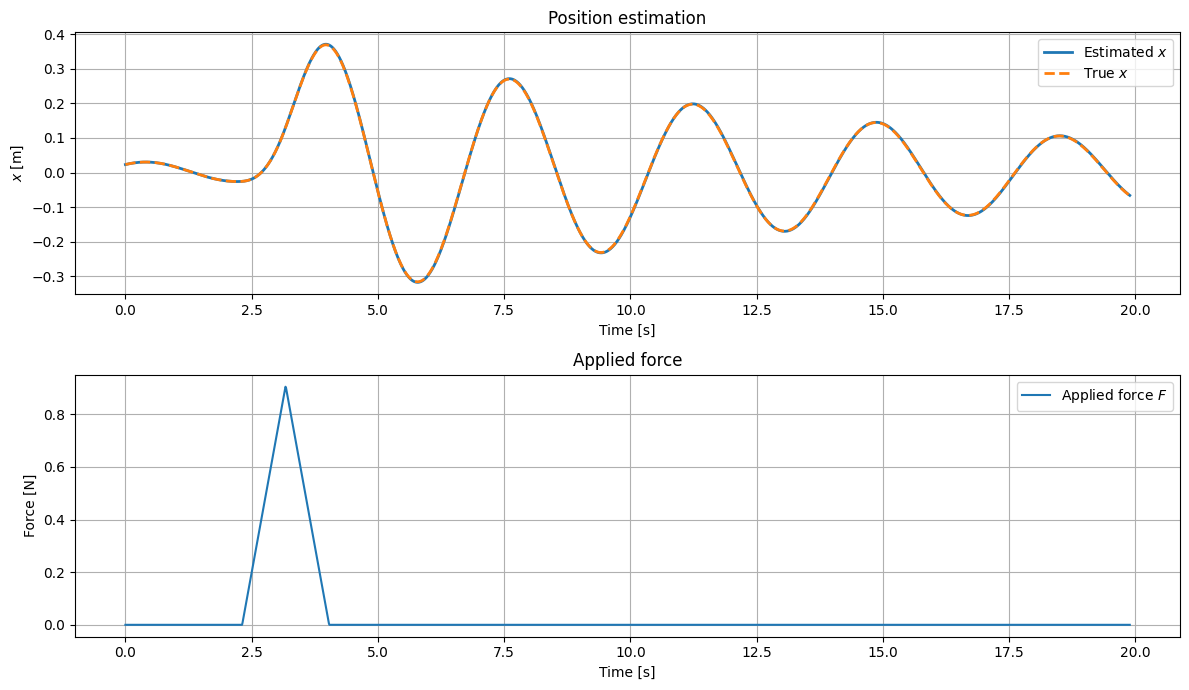

In [8]:
# Recursive plot using getSamples
msd.importPythonModel(name = model_name)
msd.neuralizeModel(sample_time=0.01)
samples = msd.getSamples(dataset='simulations', window=2000-10, index=0)
result = msd(samples, sampled=True, prediction_samples=2000-10)

#region Plotting
t = np.arange(len(result['x_n'])) * 0.01
plt.figure(figsize=(12, 7))
plt.subplot(2, 1, 1)
plt.plot(t, result['x_n'], label=r'Estimated $x$', linewidth=2)
plt.plot(t, np.array(samples['x_t']).squeeze(-1).squeeze(-1), label=r'True $x$', linestyle='--', linewidth=2)
plt.title('Position estimation')
plt.xlabel('Time [s]')
plt.ylabel(r'$x$ [m]')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t, np.array(samples['F'])[:, 0, 0], label=r'Applied force $F$')
plt.title('Applied force')
plt.xlabel('Time [s]')
plt.ylabel('Force [N]')
plt.grid()
plt.legend()
plt.tight_layout()
#endregion

plt.show()